# tmp — apr25

**Motivation**: scratch notebook <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-25/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-25/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-25/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import  plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: yoru

In [3]:
a = 'poisson_vH16-wht_t-16_b-24_k-[512]_u-10,du-10'
b = 'gold-standard_b200-ep300-lr(0.005)_temp(0.01:0.5)_gr(300)_(2025_04_22,18:28)'

tr, meta = load_model(pjoin(a, b), device=device)
meta['checkpoint']

300

In [4]:
output = tr.xtract_ftr(save_freq=500)
list(output)

100%|███████████████████████████████| 129/129 [04:05<00:00,  1.90s/it]


['r2', 'mse', 'state', 'samples', 'du_norm', 'times']

In [5]:
u = output['state'][:, -1, :].copy()
lamb_final = np.exp(u)
lamb_final.shape

(25791, 512)

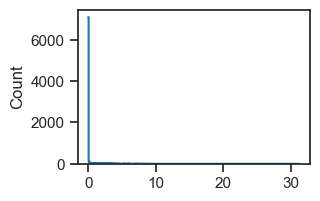

In [6]:
histplot(lamb_final[:20].ravel())
plt.show()

In [26]:
save_obj(
    obj=lamb_final,
    file_name='rates-final_t-16_b-24',
    save_dir='/mnt/sata/Dekel/vH16',
    mode='npy',
)

[PROGRESS] 'rates-final_t-16_b-24.npy' saved at
/mnt/sata/

## MNIST

In [3]:
a = 'poisson_MNIST_t-128_b-128_k-[512]_u-10,du-10'
b = 'b100-ep400-lr(0.002)_temp(0.01:0.5)_gr(3000)_(2025_04_30,10:49)'
tr, meta = load_model(pjoin(a, b), device=device)
meta['checkpoint']

380

In [4]:
from analysis.linear import clf_score

output = clf_score(tr, data_batch_sz=10000)
list(output)

100%|███████████████████████████████████| 1/1 [00:07<00:00,  7.31s/it]


['clf_accuracy', 'results_xtract']

In [5]:
output['clf_accuracy']

{'trn': {1: 0.8786666666666667,
  100: 0.98875,
  200: 0.9877666666666667,
  300: 0.9878333333333333,
  400: 0.9879666666666667,
  500: 0.9872166666666666,
  600: 0.9870666666666666,
  700: 0.987,
  800: 0.987,
  900: 0.9871333333333333,
  1000: 0.9867333333333334},
 'vld': {1: 0.8857,
  100: 0.9647,
  200: 0.9639,
  300: 0.963,
  400: 0.9641,
  500: 0.9642,
  600: 0.9639,
  700: 0.9631,
  800: 0.9627,
  900: 0.9647,
  1000: 0.9627}}

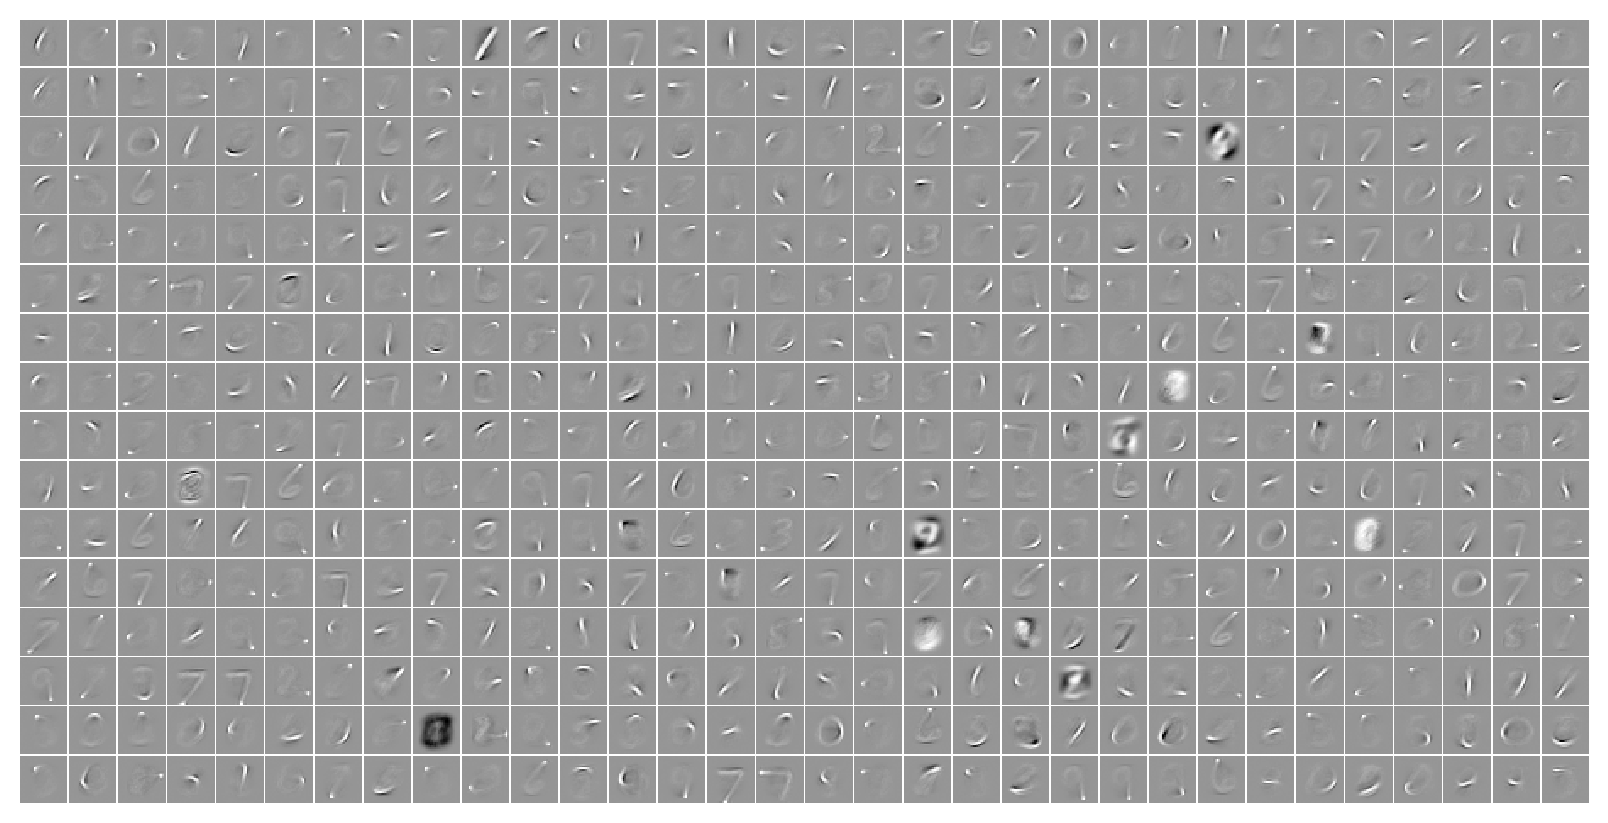

In [6]:
tr.model.show(method='abs-max');

In [3]:
pool_max = torch.nn.MaxPool2d(2)
pool_lp = torch.nn.LPPool2d(2, 2)

In [4]:
x = torch.randn((123, 128, 32, 32))
y_max = pool_max(x)
y_lp = pool_lp(x)

y_max.shape, y_lp.shape

(torch.Size([123, 128, 16, 16]), torch.Size([123, 128, 16, 16]))